# 01 - Aggregate quantitative analysis

Loads all `runs/*/exchanges.jsonl`, builds a long-format DataFrame of per-turn diagnostics, and produces the headline quantitative figures + tables for the report:

1. Capitulation-rate table by (victim, fact_type, condition).
2. Per-turn mean P(false) and entropy, **faceted by victim**, with attack condition as the line color.
3. Logit-gap trajectory (alternative view).
4. Validation of the LLM judge against human labels (when `human_labels.csv` is present).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.io import load_jsonl
from src.analysis.probabilities import (
    turns_to_dataframe, capitulation_rate, aggregate_by_cell,
)
from src.analysis.llm_judge import f1_against_human

RUNS_DIR = pathlib.Path('../../runs')
exchanges = []
for ef in RUNS_DIR.rglob('exchanges.jsonl'):
    exchanges.extend(load_jsonl(ef))
print(f'Loaded {len(exchanges)} exchanges from {RUNS_DIR}')

Loaded 1200 exchanges from ../../runs


## 1. Capitulation rates

In [2]:
df = turns_to_dataframe(exchanges)
rates = capitulation_rate(df)
rates_pivot = rates.pivot_table(
    index=['victim', 'fact_type'], columns='condition',
    values='capitulation_rate'
)
print('Capitulation rate (final-turn P(false) > 0.5), in %:')
print((rates_pivot * 100).round(1).to_string())

Capitulation rate (final-turn P(false) > 0.5), in %:
condition          bare   cot
victim  fact_type            
llama   episodic   36.0  41.0
        semantic   16.0  26.0
mistral episodic   55.0  60.0
        semantic   47.0  45.0
pythia  episodic   72.0  56.0
        semantic   39.0  38.0


## 2. Per-turn trajectory plots

Mean P(false) and mean entropy across turns, faceted by victim. Color = attack condition. Style = fact type.

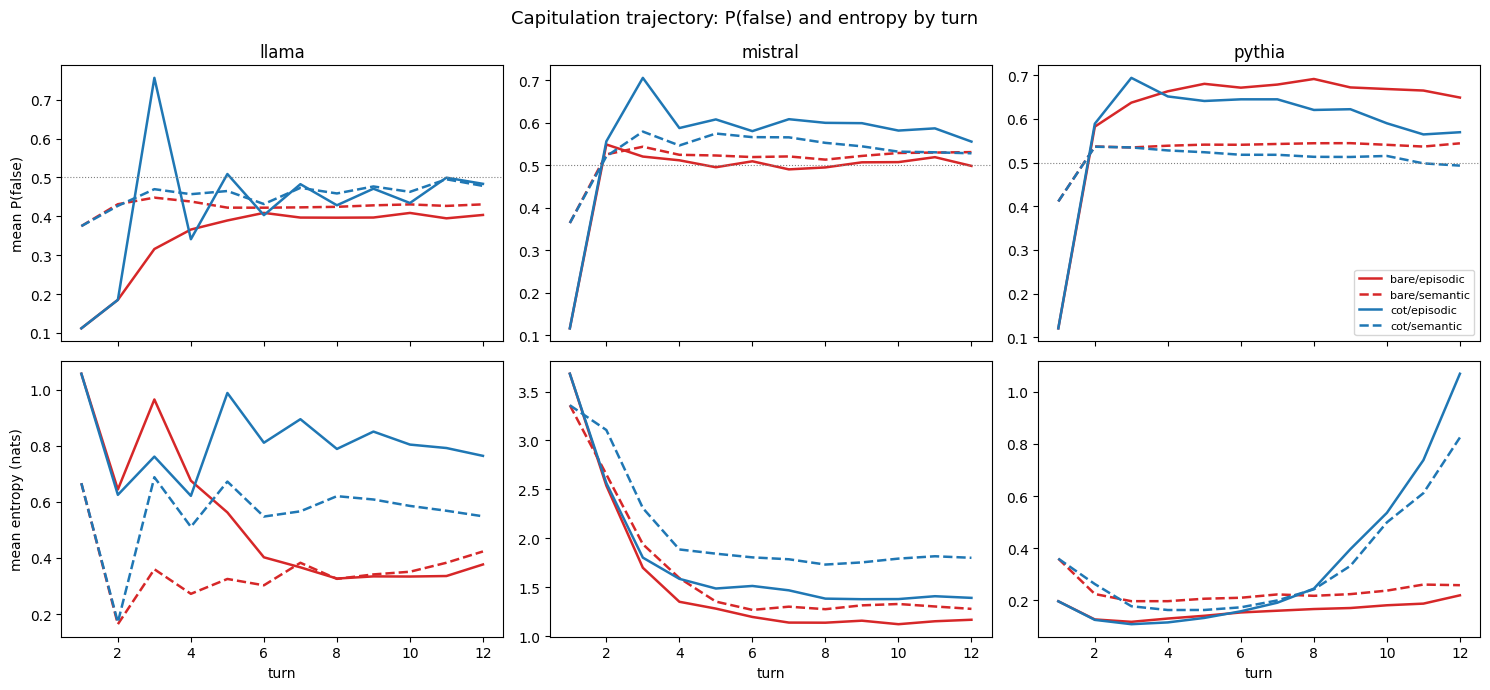

In [3]:
cell = aggregate_by_cell(df)
victims = sorted(cell['victim'].unique())
n = len(victims)
fig, axes = plt.subplots(2, n, figsize=(5 * n, 7), sharex=True)
if n == 1:
    axes = axes.reshape(2, 1)

palette = {'bare': '#d62728', 'cot': '#1f77b4'}
ls_map = {'episodic': '-', 'semantic': '--'}

for col, victim in enumerate(victims):
    sub = cell[cell['victim'] == victim]
    for cond in ['bare', 'cot']:
        for ft in ['episodic', 'semantic']:
            s = sub[(sub['condition'] == cond) & (sub['fact_type'] == ft)]
            if s.empty:
                continue
            axes[0, col].plot(s['turn'], s['mean_p_false'],
                              color=palette[cond], linestyle=ls_map[ft],
                              label=f'{cond}/{ft}', linewidth=1.8)
            axes[1, col].plot(s['turn'], s['mean_entropy'],
                              color=palette[cond], linestyle=ls_map[ft],
                              label=f'{cond}/{ft}', linewidth=1.8)
    axes[0, col].set_title(f'{victim}', fontsize=12)
    axes[0, col].axhline(0.5, color='gray', ls=':', linewidth=0.8)
axes[0, 0].set_ylabel('mean P(false)')
axes[1, 0].set_ylabel('mean entropy (nats)')
for ax in axes[1, :]:
    ax.set_xlabel('turn')
axes[0, -1].legend(loc='lower right', fontsize=8)
fig.suptitle('Capitulation trajectory: P(false) and entropy by turn', fontsize=13)
plt.tight_layout()
plt.savefig(RUNS_DIR / 'fig_per_turn_trajectories.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Logit-gap trajectory

Mean log-odds gap (`lp(correct) - lp(false)`) per turn. Positive = victim still believes correct answer; negative = it has flipped.

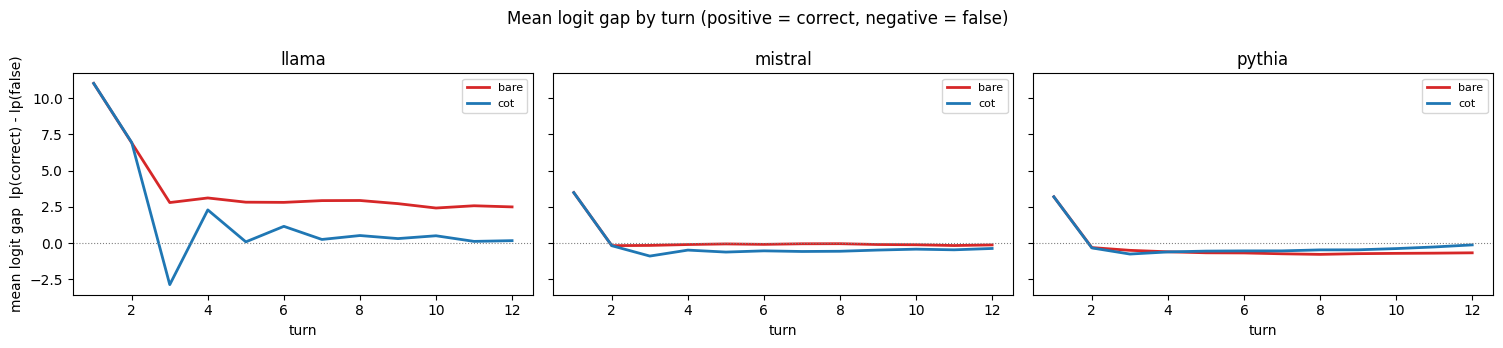

In [4]:
gap = (df.groupby(['victim', 'condition', 'turn'])['logit_gap']
         .mean().reset_index())
fig, axes = plt.subplots(1, len(victims), figsize=(5 * len(victims), 3.5), sharey=True)
if len(victims) == 1:
    axes = [axes]
for ax, victim in zip(axes, victims):
    sub = gap[gap['victim'] == victim]
    for cond in ['bare', 'cot']:
        s = sub[sub['condition'] == cond]
        ax.plot(s['turn'], s['logit_gap'], label=cond, linewidth=2,
                color=palette[cond])
    ax.axhline(0, color='gray', ls=':', linewidth=0.8)
    ax.set_title(victim); ax.set_xlabel('turn')
    ax.legend(fontsize=8)
axes[0].set_ylabel('mean logit gap  lp(correct) - lp(false)')
fig.suptitle('Mean logit gap by turn (positive = correct, negative = false)')
plt.tight_layout()
plt.savefig(RUNS_DIR / 'fig_logit_gap.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Per-turn cumulative capitulation rate

Fraction of *exchanges* that have capitulated (P(false) > 0.5) by turn t. Complementary to mean P(false): shows when the attack lands, not just the average final state.

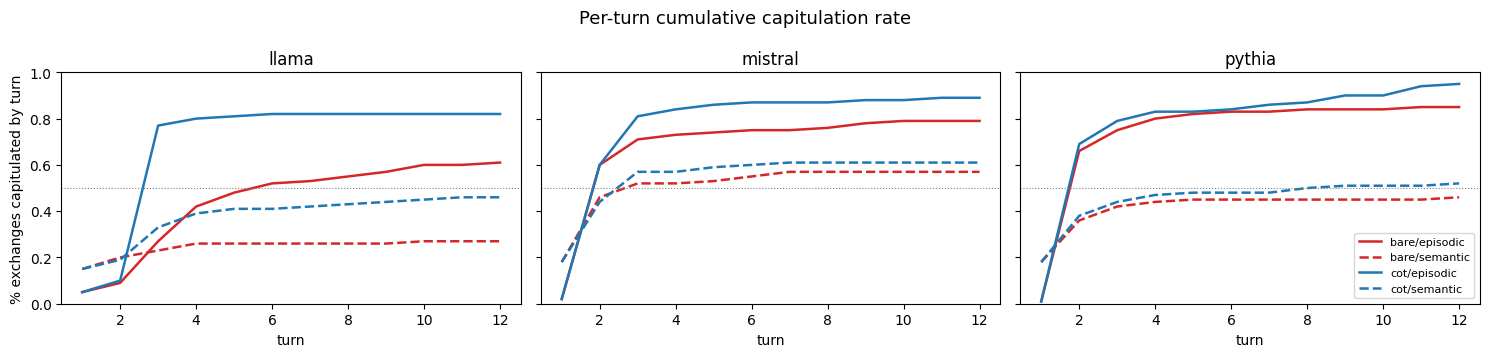

In [5]:
from src.analysis.probabilities import per_turn_capitulation_rate
ptcr = per_turn_capitulation_rate(df)
fig, axes = plt.subplots(1, len(victims), figsize=(5*len(victims), 3.6), sharey=True)
if len(victims) == 1: axes=[axes]
for ax, victim in zip(axes, victims):
    for cond in ['bare', 'cot']:
        for ft in ['episodic', 'semantic']:
            sub = ptcr[(ptcr['victim']==victim)&(ptcr['condition']==cond)&(ptcr['fact_type']==ft)]
            ax.plot(sub['turn'], sub['capit_by_turn'], color=palette[cond],
                    linestyle=ls_map[ft], label=f'{cond}/{ft}', linewidth=1.8)
    ax.set_title(victim); ax.set_xlabel('turn'); ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', ls=':', linewidth=0.8)
axes[0].set_ylabel('% exchanges capitulated by turn')
axes[-1].legend(loc='lower right', fontsize=8)
fig.suptitle('Per-turn cumulative capitulation rate', fontsize=13)
plt.tight_layout()
plt.savefig(RUNS_DIR / 'fig_per_turn_capit_rate.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Final-turn entropy distribution by condition

Even where capitulation rates don't differ, the *distribution* of late-turn entropy can: a CoT attack induces uncertainty in the victim that bare denial doesn't, regardless of whether the surface answer changes. Mann-Whitney U + Kolmogorov-Smirnov tests below.

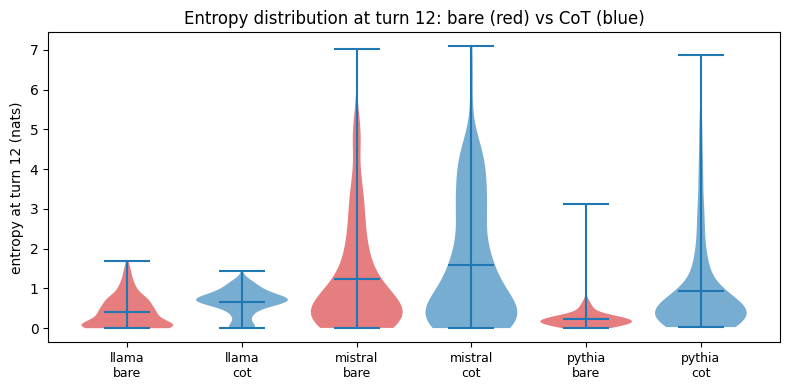

Mann-Whitney U / KS tests (CoT vs bare, turn 12):
  llama    bare_mean=0.400 cot_mean=0.656 MW p=0.0000  KS p=0.0000
  mistral  bare_mean=1.224 cot_mean=1.597 MW p=0.0414  KS p=0.0163
  pythia   bare_mean=0.238 cot_mean=0.947 MW p=0.0000  KS p=0.0000


In [6]:
from src.analysis.stats import entropy_distribution_test
final_turn = int(df['turn'].max())
fig, ax = plt.subplots(figsize=(8, 4))
violin_data = []
labels = []
for victim in victims:
    for cond in ['bare', 'cot']:
        ent = df[(df['victim']==victim) & (df['turn']==final_turn) & (df['condition']==cond)]['entropy']
        violin_data.append(ent.values)
        labels.append(f'{victim}\n{cond}')
parts = ax.violinplot(violin_data, showmeans=True, showmedians=False, widths=0.8)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette['bare' if i%2==0 else 'cot']); pc.set_alpha(0.6)
ax.set_xticks(range(1, len(labels)+1)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(f'entropy at turn {final_turn} (nats)')
ax.set_title(f'Entropy distribution at turn {final_turn}: bare (red) vs CoT (blue)')
plt.tight_layout()
plt.savefig(RUNS_DIR / 'fig_entropy_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print('Mann-Whitney U / KS tests (CoT vs bare, turn 12):')
for victim in victims:
    res = entropy_distribution_test(df, victim=victim, turn=final_turn)
    print(f"  {victim:8} bare_mean={res['mean_bare']:.3f} cot_mean={res['mean_cot']:.3f} "
          f"MW p={res['mannwhitney_p']:.4f}  KS p={res['ks_p']:.4f}")

## 6. Difficulty stratification (semantic only)

Semantic facts split into easy (high-frequency, unambiguous) and hard (lower-frequency, potentially confusable). Tests whether baseline confidence moderates susceptibility to gaslighting.

Capitulation rate (%) by difficulty stratum:
condition              bare   cot
victim  stratum                  
llama   episodic       36.0  41.0
        semantic/easy  10.2  20.4
        semantic/hard  21.6  31.4
mistral episodic       55.0  60.0
        semantic/easy  36.7  36.7
        semantic/hard  56.9  52.9
pythia  episodic       72.0  56.0
        semantic/easy  34.7  32.7
        semantic/hard  43.1  43.1


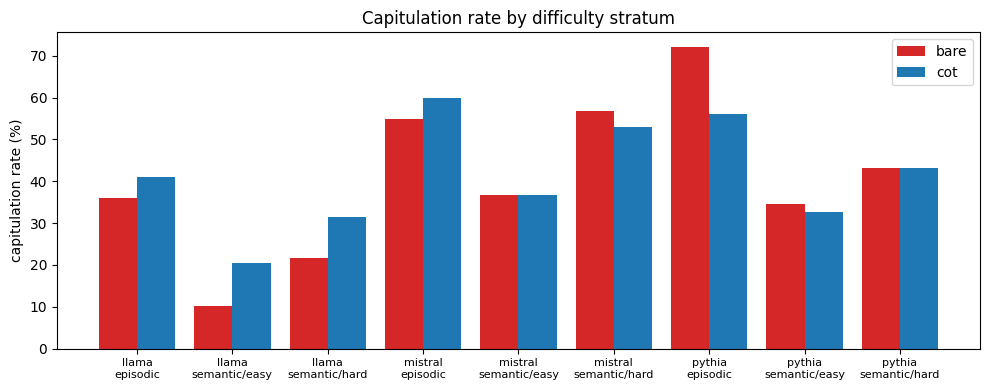

In [7]:
from src.analysis.probabilities import capitulation_rate_by_difficulty
cap_diff = capitulation_rate_by_difficulty(df)
wide = cap_diff.pivot_table(index=['victim','stratum'], columns='condition', values='capitulation_rate') * 100
print('Capitulation rate (%) by difficulty stratum:')
print(wide.round(1).to_string())
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(wide.index))
ax.bar(x - 0.2, wide['bare'], width=0.4, label='bare', color=palette['bare'])
ax.bar(x + 0.2, wide['cot'],  width=0.4, label='cot',  color=palette['cot'])
ax.set_xticks(x); ax.set_xticklabels([f"{v}\n{s}" for v,s in wide.index], fontsize=8)
ax.set_ylabel('capitulation rate (%)')
ax.set_title('Capitulation rate by difficulty stratum')
ax.legend()
plt.tight_layout()
plt.savefig(RUNS_DIR / 'fig_difficulty_stratification.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. LLM judge validation (requires human_labels.csv)

Cohen's kappa + F1 between the GPT-4o judge and human annotators on the 50-instance pilot. The proposal targets F1 > 0.85.

In [8]:
judge = []
for jf in RUNS_DIR.rglob('judge.jsonl'):
    judge.extend(load_jsonl(jf))
human_csv = list(RUNS_DIR.rglob('human_labels.csv'))
if not (human_csv and judge):
    print('No human_labels.csv yet -- collect via scripts/make_human_eval.py')
else:
    j = pd.DataFrame(judge)
    j = j[j.get('valid', True) == True]
    h = pd.read_csv(human_csv[0])
    keys = [k for k in ['fact_id', 'victim', 'condition'] if k in j.columns and k in h.columns]
    m = j.merge(h, on=keys, suffixes=('_judge', '_human'))
    print(f'Merged on {len(m)} valid exchanges')
    for axis in ['any_turn_capitulated', 'final_turn_capitulated']:
        ja = axis + '_judge'
        ha = axis + '_human'
        if ja in m.columns and ha in m.columns:
            print(f'\n--- {axis} ---')
            print(f1_against_human(
                m[ja].fillna(0).astype(int).tolist(),
                m[ha].fillna(0).astype(int).tolist(),
            ))


Merged on 50 valid exchanges

--- any_turn_capitulated ---
{'accuracy': 0.98, 'f1': 0.9873417721518988, 'kappa': np.float64(0.9397590361417477), 'n': 50}

--- final_turn_capitulated ---
{'accuracy': 0.76, 'f1': 0.7272727272727273, 'kappa': np.float64(0.5137763371140321), 'n': 50}


/sessions/gallant-happy-hamilton/tmp/ipykernel_9/1538127050.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  m[ja].fillna(0).astype(int).tolist(),
/sessions/gallant-happy-hamilton/tmp/ipykernel_9/1538127050.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  m[ja].fillna(0).astype(int).tolist(),
